# H5 — Estacionalidad: Q4 como Trimestre Dominante

**Hipótesis:** El cuarto trimestre (octubre–diciembre) supera en volumen de ventas
y revenue a cualquier otro trimestre, evidenciando estacionalidad en el e-commerce.

**Herramientas:** PySpark (date functions, window functions) · Matplotlib · Seaborn

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.window import Window

HDFS         = os.environ.get('HADOOP_NAMENODE', 'hdfs://namenode:8020')
SPARK_MASTER = os.environ.get('SPARK_MASTER',   'spark://spark-master:7077')
DATA_PATH    = f'{HDFS}/data/olist'
OUT          = '/home/jovyan/work/outputs/graficas'
os.makedirs(OUT, exist_ok=True)

MONTH_ES = {1:'Ene',2:'Feb',3:'Mar',4:'Abr',5:'May',6:'Jun',
            7:'Jul',8:'Ago',9:'Sep',10:'Oct',11:'Nov',12:'Dic'}
Q_COLORS = {'Q1':'#3498db','Q2':'#2ecc71','Q3':'#f39c12','Q4':'#e74c3c'}

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 130

In [2]:
spark = SparkSession.builder \
    .appName('H5_Estacionalidad') \
    .master(SPARK_MASTER) \
    .config('spark.hadoop.fs.defaultFS', HDFS) \
    .config('spark.sql.shuffle.partitions', '8') \
    .getOrCreate()
spark.sparkContext.setLogLevel('WARN')

26/04/17 17:37:20 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
Using Spark's default log4j profile: org/apache/spark/log4j-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


In [3]:
orders   = spark.read.csv(f'{DATA_PATH}/orders.csv',         header=True, inferSchema=True)
payments = spark.read.csv(f'{DATA_PATH}/order_payments.csv', header=True, inferSchema=True)

orders_ts = orders \
    .filter(F.col('order_status') == 'delivered') \
    .withColumn('ts',        F.to_timestamp('order_purchase_timestamp')) \
    .withColumn('year',      F.year('ts')) \
    .withColumn('month',     F.month('ts')) \
    .withColumn('trimestre', F.concat(F.lit('Q'), F.quarter('ts')))

pay_per_order = payments.groupBy('order_id').agg(F.sum('payment_value').alias('revenue'))
analysis      = orders_ts.join(pay_per_order, 'order_id')
analysis.cache()
print(f'Órdenes: {analysis.count():,}')

Órdenes: 62,802


### Gráfica 1 — Serie de tiempo mensual (volumen + revenue)

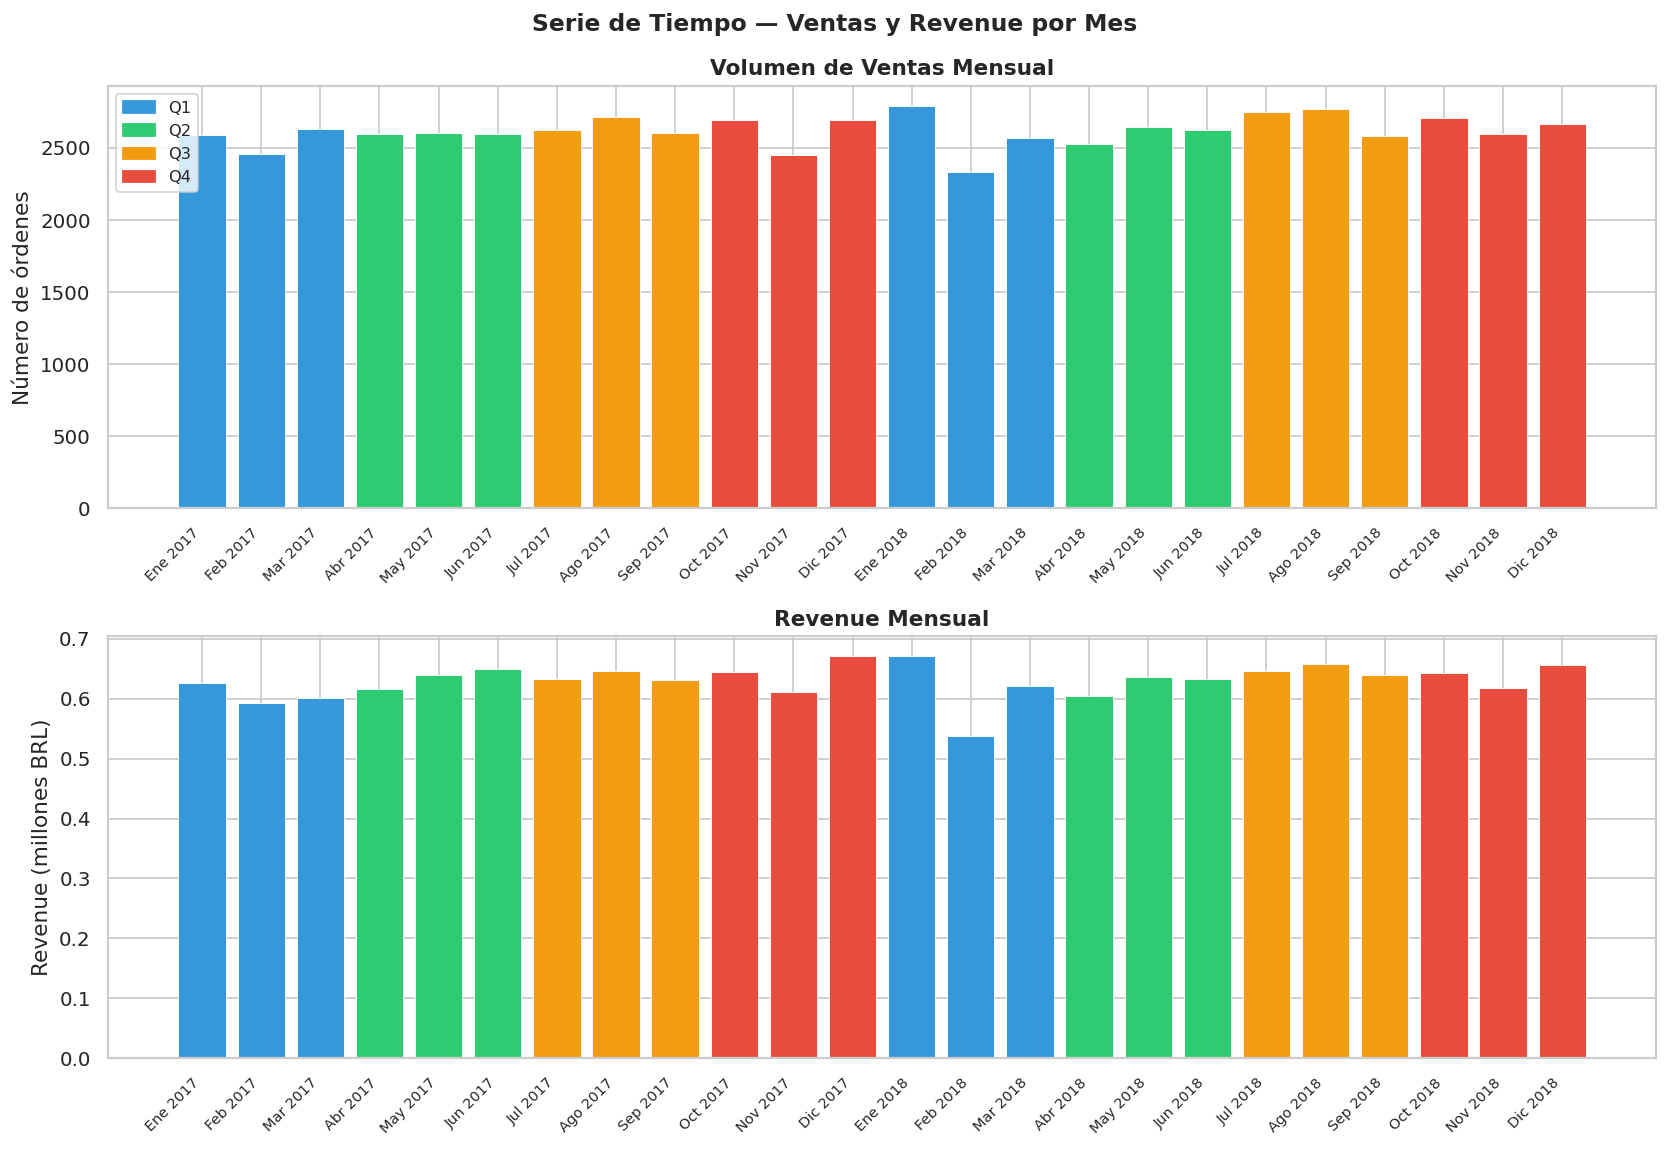

In [4]:
monthly = analysis.groupBy('year', 'month', 'trimestre').agg(
    F.count('order_id').alias('n_ordenes'),
    F.sum('revenue').alias('revenue_total')
).orderBy('year', 'month').toPandas()

monthly['mes_label'] = monthly['month'].map(MONTH_ES) + ' ' + monthly['year'].astype(str)
monthly['q_color']   = monthly['trimestre'].map(Q_COLORS)

fig, axes = plt.subplots(2, 1, figsize=(13, 9))

axes[0].bar(range(len(monthly)), monthly['n_ordenes'],
            color=monthly['q_color'], edgecolor='white', linewidth=0.5)
axes[0].set_xticks(range(len(monthly)))
axes[0].set_xticklabels(monthly['mes_label'], rotation=45, ha='right', fontsize=8)
axes[0].set_ylabel('Número de órdenes')
axes[0].set_title('Volumen de Ventas Mensual', fontweight='bold')
axes[0].legend(handles=[mpatches.Patch(color=v, label=k) for k, v in Q_COLORS.items()],
               loc='upper left', fontsize=9)

axes[1].bar(range(len(monthly)), monthly['revenue_total'] / 1e6,
            color=monthly['q_color'], edgecolor='white', linewidth=0.5)
axes[1].set_xticks(range(len(monthly)))
axes[1].set_xticklabels(monthly['mes_label'], rotation=45, ha='right', fontsize=8)
axes[1].set_ylabel('Revenue (millones BRL)')
axes[1].set_title('Revenue Mensual', fontweight='bold')

plt.suptitle('Serie de Tiempo — Ventas y Revenue por Mes', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUT}/H5_serie_temporal.png', bbox_inches='tight')
plt.show()

### Gráfica 2 — Comparativo trimestral (volumen, revenue, ticket)

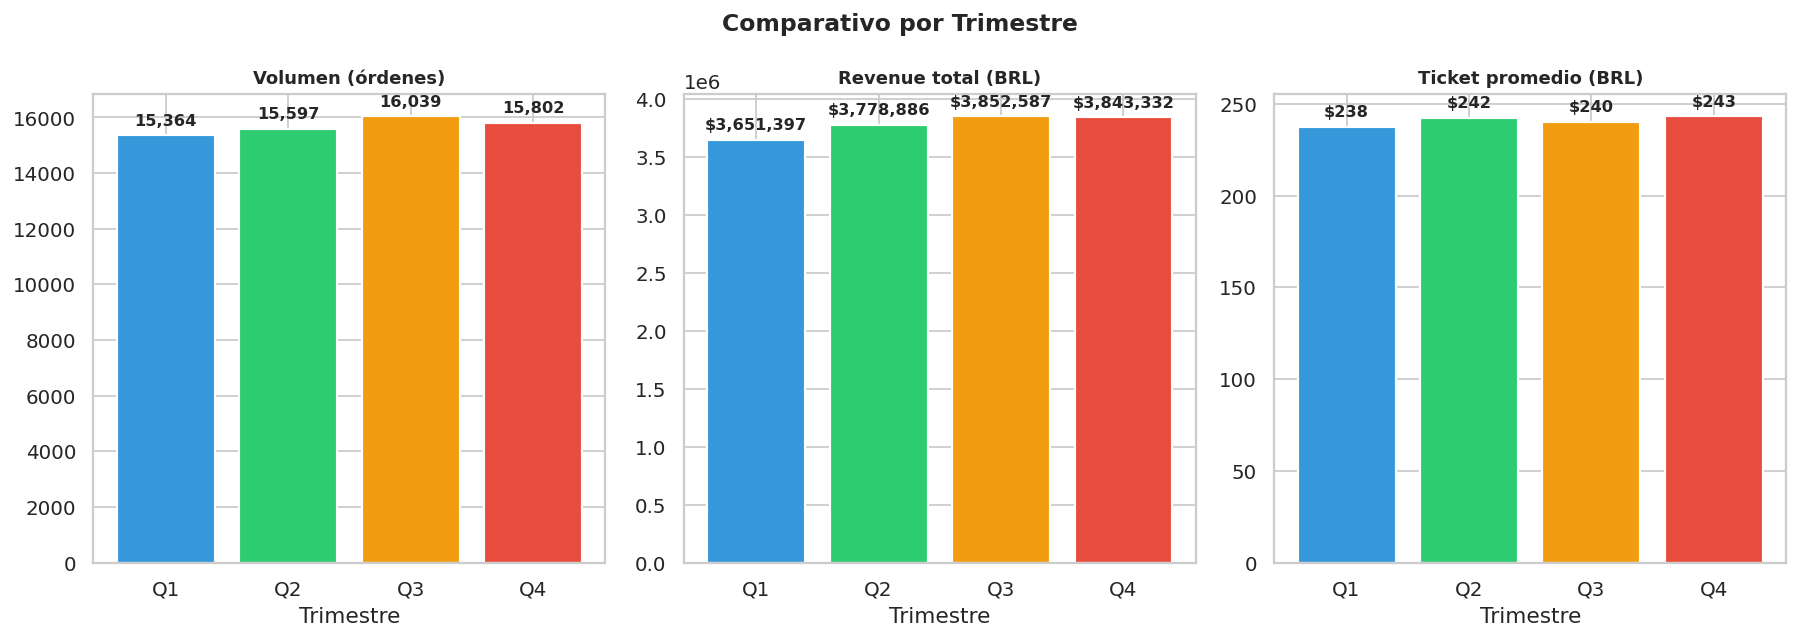

trimestre  n_ordenes  revenue_total  ticket_promedio
       Q1      15364     3651396.76       237.659253
       Q2      15597     3778886.01       242.282876
       Q3      16039     3852586.72       240.201180
       Q4      15802     3843332.12       243.218081


In [5]:
quarterly = analysis.groupBy('trimestre').agg(
    F.count('order_id').alias('n_ordenes'),
    F.sum('revenue').alias('revenue_total'),
    F.avg('revenue').alias('ticket_promedio')
).orderBy('trimestre').toPandas()
quarterly['q_color'] = quarterly['trimestre'].map(Q_COLORS)

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for ax, col, label, fmt in zip(
    axes,
    ['n_ordenes', 'revenue_total', 'ticket_promedio'],
    ['Volumen (órdenes)', 'Revenue total (BRL)', 'Ticket promedio (BRL)'],
    ['{:,.0f}', '${:,.0f}', '${:,.0f}']
):
    bars = ax.bar(quarterly['trimestre'], quarterly[col],
                  color=quarterly['q_color'], edgecolor='white', linewidth=1.2)
    ax.bar_label(bars, labels=[fmt.format(v) for v in quarterly[col]],
                 padding=4, fontsize=9, fontweight='bold')
    ax.set_title(label, fontweight='bold', fontsize=10)
    ax.set_xlabel('Trimestre')

plt.suptitle('Comparativo por Trimestre', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUT}/H5_comparativo_trimestral.png', bbox_inches='tight')
plt.show()
print(quarterly[['trimestre','n_ordenes','revenue_total','ticket_promedio']].to_string(index=False))

### Gráfica 3 — Heatmap: Día de semana vs Mes

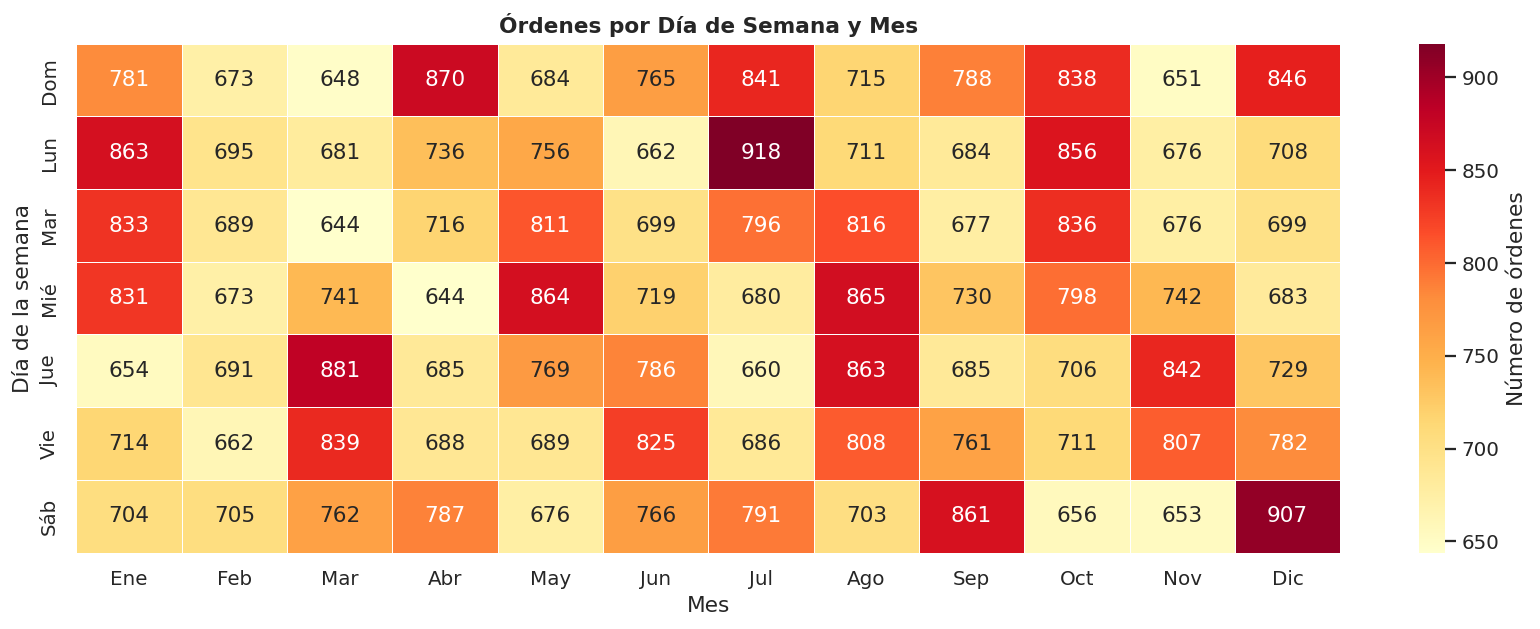

In [6]:
hm = analysis \
    .withColumn('dia_semana', F.dayofweek('ts')) \
    .groupBy('month', 'dia_semana').count().toPandas()

pivot = hm.pivot(index='dia_semana', columns='month', values='count').fillna(0)
pivot.index = ['Dom','Lun','Mar','Mié','Jue','Vie','Sáb'][:len(pivot)]
pivot.columns = [MONTH_ES.get(c, c) for c in pivot.columns]

fig, ax = plt.subplots(figsize=(13, 5))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Número de órdenes'})
ax.set_title('Órdenes por Día de Semana y Mes', fontsize=12, fontweight='bold')
ax.set_xlabel('Mes')
ax.set_ylabel('Día de la semana')
plt.tight_layout()
plt.savefig(f'{OUT}/H5_heatmap_temporal.png', bbox_inches='tight')
plt.show()

### Conclusión H5

In [7]:
q4      = quarterly[quarterly['trimestre'] == 'Q4'].iloc[0]
max_q   = quarterly.loc[quarterly['n_ordenes'].idxmax()]
avg_no_q4 = quarterly[quarterly['trimestre'] != 'Q4']['n_ordenes'].mean()
pct_above = (q4['n_ordenes'] - avg_no_q4) / avg_no_q4 * 100

print(f'Trimestre con mayor volumen: {max_q["trimestre"]} ({max_q["n_ordenes"]:,} órdenes)')
print(f'Q4 — Órdenes:  {q4["n_ordenes"]:,}')
print(f'Q4 — Revenue:  ${q4["revenue_total"]:,.2f}')
print(f'Q4 supera en {pct_above:.1f}% el promedio de otros trimestres.')
print()
if max_q['trimestre'] == 'Q4':
    print('CONCLUSIÓN: La hipótesis SE CONFIRMA.')
    print('  Q4 (oct-dic) es el trimestre dominante en volumen y revenue.')
    print('  Patrón atribuible a temporada navideña y Black Friday.')
else:
    print(f'CONCLUSIÓN: Trimestre dominante = {max_q["trimestre"]}.')

Trimestre con mayor volumen: Q3 (16,039 órdenes)
Q4 — Órdenes:  15,802
Q4 — Revenue:  $3,843,332.12
Q4 supera en 0.9% el promedio de otros trimestres.

CONCLUSIÓN: Trimestre dominante = Q3.


In [8]:
spark.stop()